# Part IV — Weight-Tuned Soft-Constraint PINN (Repo-Aligned)

This notebook expects the repo layout you shared and reads/writes under `PIML examples/…`. See Section 1 if you need to convert CSV→NPZ inside the repo.

## 0) Paths (Windows-safe)

In [1]:

import os, sys, numpy as np, tensorflow as tf, matplotlib.pyplot as plt, glob
from pathlib import Path
print("Python:", sys.version)
print("TensorFlow:", tf.__version__)

REPO_ROOT = Path.cwd()
PBM_DIR   = REPO_ROOT / "physics based modeling" / "data"
NPZ_DIR   = REPO_ROOT / "PIML examples" / "data"
OUT_PRED  = REPO_ROOT / "PIML examples" / "model_predictions" / "pinn_soft"
OUT_CURVE = REPO_ROOT / "PIML examples" / "training_curves"
for p in [NPZ_DIR, OUT_PRED, OUT_CURVE]:
    p.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO_ROOT)
print("CSV base :", PBM_DIR)
print("NPZ dir  :", NPZ_DIR)
print("Out pred :", OUT_PRED)
print("Curves   :", OUT_CURVE)


Python: 3.9.13 (main, Aug 25 2022, 23:51:50) [MSC v.1916 64 bit (AMD64)]
TensorFlow: 2.9.1
Repo root: C:\Users\feder\Downloads\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main
CSV base : C:\Users\feder\Downloads\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\physics based modeling\data
NPZ dir  : C:\Users\feder\Downloads\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\PIML examples\data
Out pred : C:\Users\feder\Downloads\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\PIML examples\model_predictions\pinn_soft
Curves   : C:\Users\feder\Do

In [2]:
%%javascript
Jupyter.notebook.set_autosave_interval(0)  // disables autosave

<IPython.core.display.Javascript object>

In [3]:
# --- Metrics for training history ---
import tensorflow as tf
from tensorflow import keras

@tf.function
def rmse_x_metric(y_true, y_pred):
    # y_true: [x1, v1, a1, k0_true, F1]; y_pred: [x1_pred, k0_pred]
    x1_t = y_true[:, 0:1]
    x1_p = y_pred[:, 0:1]
    return tf.sqrt(tf.reduce_mean(tf.square(x1_p - x1_t)))

@tf.function
def rmse_k_metric(y_true, y_pred):
    k0_t = y_true[:, 3:4]
    k0_p = y_pred[:, 1:2]
    return tf.sqrt(tf.reduce_mean(tf.square(k0_p - k0_t)))

@tf.function
def phys_mse_metric(y_true, y_pred):
    # physics residual MSE at t+1 using predicted k_t & x_{t+1}, measured v_{t+1}, a_{t+1}, F_{t+1}
    x1_p = y_pred[:, 0:1]; k0_p = y_pred[:, 1:2]
    v1_t = y_true[:, 1:2]; a1_t = y_true[:, 2:3]; F1_t = y_true[:, 4:5]
    return tf.reduce_mean(tf.square(tf.constant(m, tf.float32)*a1_t +
                                    tf.constant(c, tf.float32)*v1_t +
                                    k0_p*x1_p - F1_t))

class LogWPhys(keras.callbacks.Callback):
    """Adds current w_phys to logs so it lands in history.csv."""
    def __init__(self, w_phys_var): super().__init__(); self.w = w_phys_var
    def on_epoch_end(self, epoch, logs=None):
        if logs is not None:
            logs["w_phys"] = float(self.w.numpy())


## 1) Convert CSV → NPZ

In [4]:

import numpy as np
from pathlib import Path

def pack_folder_to_npz(folder: Path, out_stem: str):
    files = sorted(folder.glob("test_*.csv"),
                   key=lambda p: int(p.stem.split("_")[-1]))
    if not files:
        print(f"[WARN] No CSVs in {folder}")
        return None
    sample = np.loadtxt(files[0], delimiter=',')
    all_data = np.zeros((len(files),) + sample.shape, dtype=float)
    for i, f in enumerate(files):
        all_data[i] = np.loadtxt(f, delimiter=',')
    out_path = (Path.cwd() / "PIML examples" / "data" / f"{out_stem}.npz")
    np.savez_compressed(out_path, data=all_data)
    print(f"[OK] Wrote {out_path} with shape={all_data.shape}")
    return out_path

def write_pinn_test(pinn_csv: Path, out_name="pinn_test_0.npy"):
    if pinn_csv.exists():
        arr = np.loadtxt(pinn_csv, delimiter=',')
        out_path = (Path.cwd() / "PIML examples" / "data" / out_name)
        np.save(out_path, arr)
        print(f"[OK] Wrote {out_path} with shape={arr.shape}")
        return out_path
    print("[WARN] PINN test CSV not found:", pinn_csv)

# Example usage (run when needed):
#wf_npz = pack_folder_to_npz(PBM_DIR / "with_friction", "with_friction")
#nf_npz = pack_folder_to_npz(PBM_DIR / "no_friction",   "no_friction")
#pt_npy = write_pinn_test(PBM_DIR / "pinn_data" / "test_0.csv")


## 2) Load dataset (downsample to 50 Hz; split 80/20 by experiments)

In [5]:

from pathlib import Path

def load_npz(npz_path: Path, downsample=20):
    data = np.load(npz_path)['data']
    data = data[:, :-1:downsample, :]
    t = data[0, :, 0]; x = data[:, :, 1]; v = data[:, :, 2]
    a = data[:, :, 3]; k = data[:, :, 4]; F = data[:, :, 5]
    return t.astype(np.float32), x.astype(np.float32), v.astype(np.float32), a.astype(np.float32), k.astype(np.float32), F.astype(np.float32)

USE_WITH_FRICTION = True
npz_file = (Path.cwd() / "PIML examples" / "data" / ("with_friction.npz" if USE_WITH_FRICTION else "no_friction.npz"))
if not npz_file.exists():
    raise FileNotFoundError(f"{npz_file} not found. Run the CSV→NPZ cell in Section 1, or copy NPZ here.")
t, x, v, a, k, F = load_npz(npz_file, downsample=20)
print("Loaded:", npz_file, "| shapes:", x.shape, v.shape, a.shape, k.shape, F.shape)


Loaded: C:\Users\feder\Downloads\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\PIML examples\data\with_friction.npz | shapes: (100, 6000) (100, 6000) (100, 6000) (100, 6000) (100, 6000)


## 3) Make (t→t+1) pairs & tf.data pipelines (repo policy)

In [6]:

import tensorflow as tf, numpy as np

def make_pair_dataset(t, x, v, a, k, F, train_n=80, batch=256, shuffle=True):
    t01 = (t - t.min()) / (t.max() - t.min() + 1e-9)
    T_tile = np.tile(t01[None, :], (x.shape[0], 1))
    X = np.stack([x[:, :-1], v[:, :-1], F[:, :-1], T_tile[:, :-1]], axis=-1)
    Y = np.stack([x[:, 1:], v[:, 1:], a[:, 1:], k[:, :-1], F[:, 1:]], axis=-1)
    X_tr = X[:train_n].reshape(-1, 4).astype(np.float32)
    Y_tr = Y[:train_n].reshape(-1, 5).astype(np.float32)
    X_va = X[train_n:].reshape(-1, 4).astype(np.float32)
    Y_va = Y[train_n:].reshape(-1, 5).astype(np.float32)
    mu = X_tr[:, :3].mean(axis=0, keepdims=True)
    std = X_tr[:, :3].std(axis=0, keepdims=True) + 1e-8
    X_tr[:, :3] = (X_tr[:, :3] - mu) / std
    X_va[:, :3] = (X_va[:, :3] - mu) / std
    meta = {"mu": mu, "std": std}
    ds_tr = tf.data.Dataset.from_tensor_slices((X_tr, Y_tr))
    ds_va = tf.data.Dataset.from_tensor_slices((X_va, Y_va))
    if shuffle: ds_tr = ds_tr.shuffle(65536, reshuffle_each_iteration=True)
    ds_tr = ds_tr.batch(batch).prefetch(tf.data.AUTOTUNE)
    ds_va = ds_va.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds_tr, ds_va, meta

train_ds, val_ds, meta = make_pair_dataset(t, x, v, a, k, F, train_n=80, batch=256)
train_ds, val_ds


(<PrefetchDataset element_spec=(TensorSpec(shape=(None, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>,
 <PrefetchDataset element_spec=(TensorSpec(shape=(None, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>)

## 4) Model: `[x,v,F,t] → [x_{t+1}, k_t]`

In [7]:

from tensorflow import keras

def make_pinn(hidden=64, depth=3, act='tanh'):
    inp = keras.Input(shape=(4,), name="inp_[x,v,F,t]")
    z = inp
    for _ in range(depth):
        z = keras.layers.Dense(hidden, activation=act)(z)
    out_x1 = keras.layers.Dense(1, activation=None, name="x1")(z)
    out_k0 = keras.layers.Dense(1, activation=None, name="k0")(z)
    return keras.Model(inp, keras.layers.Concatenate(name="pred")([out_x1, out_k0]))

model = make_pinn(hidden=64, depth=3, act='tanh')
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 inp_[x,v,F,t] (InputLayer)     [(None, 4)]          0           []                               
                                                                                                  
 dense (Dense)                  (None, 64)           320         ['inp_[x,v,F,t][0][0]']          
                                                                                                  
 dense_1 (Dense)                (None, 64)           4160        ['dense[0][0]']                  
                                                                                                  
 dense_2 (Dense)                (None, 64)           4160        ['dense_1[0][0]']                
                                                                                              

## 5) Composite loss (+ adaptive physics weight option)

In [8]:

import tensorflow as tf

def make_loss(m, c, w_x, w_v, w_a, w_k, w_phys):
    w_phys_var = tf.Variable(w_phys, trainable=False, dtype=tf.float32, name="w_phys")
    @tf.function
    def loss_fn(y_true, y_pred):
        x1_t = y_true[:, 0:1]; v1_t = y_true[:, 1:2]; a1_t = y_true[:, 2:3]
        k0_t = y_true[:, 3:4]; F1_t = y_true[:, 4:5]
        x1_p = y_pred[:, 0:1]; k0_p = y_pred[:, 1:2]

        Lx = tf.reduce_mean(tf.square(x1_p - x1_t)) if w_x>0 else 0.0
        Lv = tf.reduce_mean(tf.square(v1_t - v1_t)) if w_v>0 else 0.0
        La = tf.reduce_mean(tf.square(a1_t - a1_t)) if w_a>0 else 0.0
        Lk = tf.reduce_mean(tf.square(k0_p - k0_t)) if w_k>0 else 0.0

        r1 = m*a1_t + c*v1_t + k0_p*x1_p - F1_t
        Lphys = tf.reduce_mean(tf.square(r1))
        return w_x*Lx + w_v*Lv + w_a*La + w_k*Lk + w_phys_var*Lphys
    return loss_fn, w_phys_var

class AdaptivePhysicsWeight(tf.keras.callbacks.Callback):
    def __init__(self, model, w_phys_var, tol=1e-3, alpha_up=0.25, alpha_down=0.05, w_min=1e-4, w_max=1e3, m=1.0, c=0.2):
        super().__init__()
        self.net = model; self.w = w_phys_var
        self.tol = tol; self.alpha_up = alpha_up; self.alpha_down = alpha_down
        self.w_min = w_min; self.w_max = w_max
        self.m = tf.constant(m, tf.float32); self.c = tf.constant(c, tf.float32)
    def on_epoch_end(self, epoch, logs=None):
        try: Xb, Yb = next(iter(self.validation_data))
        except Exception: return
        pred = self.net.predict(Xb, verbose=0)
        x1_p = pred[:, :1]; k0_p = pred[:, 1:2]
        x1_t = Yb[:, 0:1]; v1_t = Yb[:, 1:2]; a1_t = Yb[:, 2:3]; F1_t = Yb[:, 4:5]
        r1 = self.m*a1_t + self.c*v1_t + k0_p*x1_p - F1_t
        mse = float(tf.reduce_mean(tf.square(r1)).numpy())
        w_now = float(self.w.numpy())
        if mse > self.tol: w_now = min(self.w_max, w_now*(1+self.alpha_up))
        else:              w_now = max(self.w_min, w_now*(1-self.alpha_down))
        self.w.assign(w_now)
        print(f"[Adaptive] epoch={epoch} val_phys_mse={mse:.3e} -> w_phys={w_now:.3e}")


## 6) Train (manual vs adaptive)

Epoch 1/40
1875/1875 [==============================] - 8s 4ms/step - loss: 99299.0000 - rmse_x_metric: 0.1967 - rmse_k_metric: 995.4991 - phys_mse_metric: 8.9780 - val_loss: 86590.4141 - val_rmse_x_metric: 0.0303 - val_rmse_k_metric: 854.1472 - val_phys_mse_metric: 2.4634 - lr: 0.0010 - w_phys: 1.0000
Epoch 2/40
1875/1875 [==============================] - 6s 3ms/step - loss: 78882.1172 - rmse_x_metric: 0.0494 - rmse_k_metric: 887.2037 - phys_mse_metric: 2.5410 - val_loss: 68383.5000 - val_rmse_x_metric: 0.0138 - val_rmse_k_metric: 739.9913 - val_phys_mse_metric: 1.6258 - lr: 0.0010 - w_phys: 1.0000
Epoch 3/40
1875/1875 [==============================] - 6s 3ms/step - loss: 61836.1719 - rmse_x_metric: 0.0258 - rmse_k_metric: 785.3735 - phys_mse_metric: 2.2508 - val_loss: 53131.3281 - val_rmse_x_metric: 0.0089 - val_rmse_k_metric: 628.6032 - val_phys_mse_metric: 1.9709 - lr: 0.0010 - w_phys: 1.0000
Epoch 4/40
1875/1875 [==============================] - 6s 3ms/step - loss: 47621.2930 -

Epoch 13/40
1875/1875 [==============================] - 6s 3ms/step - loss: 1144.5029 - rmse_x_metric: 0.0027 - rmse_k_metric: 105.8583 - phys_mse_metric: 7.4364 - val_loss: 763.7783 - val_rmse_x_metric: 0.0024 - val_rmse_k_metric: 64.8089 - val_phys_mse_metric: 4.6824 - lr: 0.0010 - w_phys: 1.0000
Epoch 14/40
1875/1875 [==============================] - 6s 3ms/step - loss: 485.4698 - rmse_x_metric: 0.0026 - rmse_k_metric: 68.5313 - phys_mse_metric: 7.4667 - val_loss: 321.7971 - val_rmse_x_metric: 0.0019 - val_rmse_k_metric: 43.9666 - val_phys_mse_metric: 3.4418 - lr: 0.0010 - w_phys: 1.0000
Epoch 15/40
1875/1875 [==============================] - 6s 3ms/step - loss: 198.8518 - rmse_x_metric: 0.0025 - rmse_k_metric: 43.4724 - phys_mse_metric: 7.2730 - val_loss: 159.7292 - val_rmse_x_metric: 0.0016 - val_rmse_k_metric: 30.2816 - val_phys_mse_metric: 3.2308 - lr: 0.0010 - w_phys: 1.0000
Epoch 16/40
1875/1875 [==============================] - 6s 3ms/step - loss: 110.9739 - rmse_x_metric

Epoch 25/40
1875/1875 [==============================] - 6s 3ms/step - loss: 72.0236 - rmse_x_metric: 0.0016 - rmse_k_metric: 25.7734 - phys_mse_metric: 4.1245 - val_loss: 100.8582 - val_rmse_x_metric: 8.6981e-04 - val_rmse_k_metric: 18.9151 - val_phys_mse_metric: 1.0637 - lr: 0.0010 - w_phys: 1.0000
Epoch 26/40
1875/1875 [==============================] - 7s 3ms/step - loss: 71.1217 - rmse_x_metric: 0.0016 - rmse_k_metric: 25.5656 - phys_mse_metric: 4.3840 - val_loss: 156.8704 - val_rmse_x_metric: 0.0072 - val_rmse_k_metric: 18.4759 - val_phys_mse_metric: 63.8627 - lr: 0.0010 - w_phys: 1.0000
Epoch 27/40
1875/1875 [==============================] - 6s 3ms/step - loss: 69.4319 - rmse_x_metric: 0.0015 - rmse_k_metric: 25.3484 - phys_mse_metric: 3.7668 - val_loss: 104.2898 - val_rmse_x_metric: 0.0034 - val_rmse_k_metric: 17.9435 - val_phys_mse_metric: 9.6627 - lr: 0.0010 - w_phys: 1.0000
Epoch 28/40
1875/1875 [==============================] - 6s 3ms/step - loss: 68.8792 - rmse_x_metric:

Epoch 37/40
1875/1875 [==============================] - 7s 4ms/step - loss: 61.3352 - rmse_x_metric: 0.0015 - rmse_k_metric: 23.7695 - phys_mse_metric: 3.5325 - val_loss: 88.0903 - val_rmse_x_metric: 0.0010 - val_rmse_k_metric: 17.2090 - val_phys_mse_metric: 2.0750 - lr: 0.0010 - w_phys: 1.0000
Epoch 38/40
1875/1875 [==============================] - 7s 4ms/step - loss: 61.3338 - rmse_x_metric: 0.0014 - rmse_k_metric: 23.5955 - phys_mse_metric: 4.3005 - val_loss: 89.3551 - val_rmse_x_metric: 6.1926e-04 - val_rmse_k_metric: 17.5622 - val_phys_mse_metric: 0.5448 - lr: 0.0010 - w_phys: 1.0000
Epoch 39/40
1875/1875 [==============================] - 10s 5ms/step - loss: 60.3798 - rmse_x_metric: 0.0014 - rmse_k_metric: 23.5002 - phys_mse_metric: 3.8948 - val_loss: 90.9041 - val_rmse_x_metric: 0.0011 - val_rmse_k_metric: 17.4579 - val_phys_mse_metric: 0.8883 - lr: 0.0010 - w_phys: 1.0000
Epoch 40/40
1875/1875 [==============================] - 10s 5ms/step - loss: 59.2616 - rmse_x_metric: 0

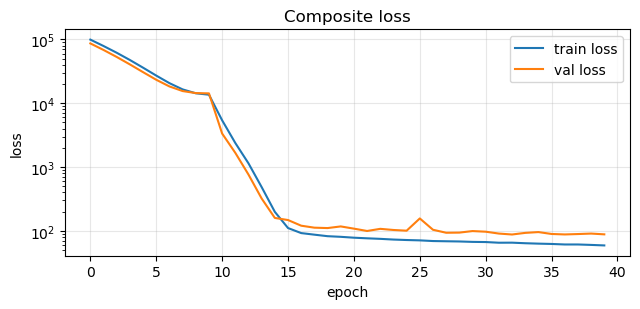

In [9]:
m, c = 1.0, 0.2
w_x, w_v, w_a, w_k, w_phys = 1.0, 0.0, 0.0, 0.1, 1.0
EPOCHS = 40
ADAPTIVE = True

# -- compile with metrics
loss_fn, w_phys_var = make_loss(tf.constant(m, tf.float32),
                                tf.constant(c, tf.float32),
                                w_x, w_v, w_a, w_k, w_phys)

opt = tf.keras.optimizers.Adam(1e-3)
model.compile(optimizer=opt,
              loss=loss_fn,
              metrics=[rmse_x_metric, rmse_k_metric, phys_mse_metric])

# -- callbacks
cbs = [
    tf.keras.callbacks.ModelCheckpoint(filepath=str(OUT_PRED / "best_weights.keras"),
                                       save_best_only=True, monitor="val_loss", mode="min"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_val_loss" if ADAPTIVE else "val_loss",
                                         factor=0.5, patience=5, min_lr=1e-5),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    LogWPhys(w_phys_var),
]
if ADAPTIVE:
    cbs.append(AdaptivePhysicsWeight(model, w_phys_var, tol=1e-3, alpha_up=0.25,
                                     alpha_down=0.05, w_min=1e-4, w_max=1e3, m=m, c=c))

# -- train
hist = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=cbs, verbose=1)

# Plot composite loss from the fit() history
import matplotlib.pyplot as plt

plt.figure(figsize=(6.5,3.2))
plt.plot(hist.history["loss"], label="train loss")
plt.plot(hist.history["val_loss"], label="val loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Composite loss")
plt.yscale("log")           # comment out if you prefer linear scale
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()

# also save to repo-style curves folder
plt.savefig(OUT_CURVE / "pinn_soft_loss.png", dpi=300)
print("Saved loss plot to:", OUT_CURVE / "pinn_soft_loss.png")

# -- save history with metrics
import pandas as pd
hist_df = pd.DataFrame(hist.history)
hist_df.to_csv(OUT_CURVE / "pinn_soft_history.csv", index=False)
display_cols = [c for c in hist_df.columns if "loss" in c or "rmse" in c or "phys" in c or c=="w_phys"]
print(hist_df[display_cols].tail(3))
print("History saved to:", OUT_CURVE / "pinn_soft_history.csv")


## 7) Export predictions and plots

Saved predictions to: C:\Users\feder\Downloads\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\PIML examples\model_predictions\pinn_soft
Saved example plots to: C:\Users\feder\Downloads\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\PIML examples\model_predictions\pinn_soft


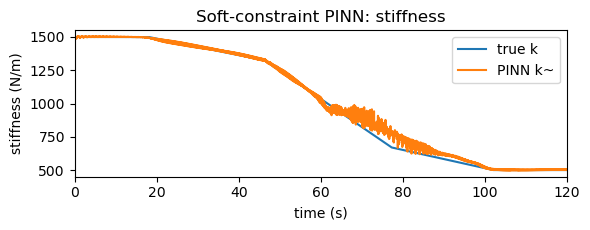

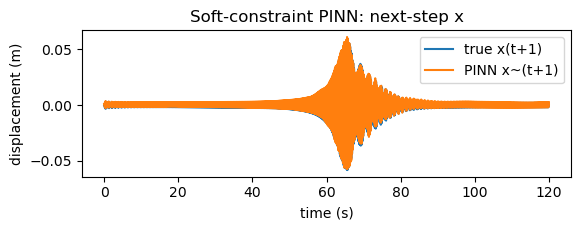

In [10]:

n_exp, T = x.shape
t01 = (t - t.min())/(t.max()-t.min()+1e-9)
T_tile = np.tile(t01[None, :], (n_exp, 1))
X_val = np.stack([x[80:, :-1], v[80:, :-1], F[80:, :-1], T_tile[80:, :-1]], axis=-1).reshape(-1,4).astype(np.float32)
mu = meta["mu"].astype(np.float32); std = meta["std"].astype(np.float32)
X_val[:, :3] = (X_val[:, :3] - mu)/std
pred = model.predict(X_val, verbose=0).reshape(x[80:, :-1].shape + (2,))
x1_pred = pred[..., 0]; k0_pred = pred[..., 1]
np.save(OUT_PRED / "x1_pred.npy", x1_pred)
np.save(OUT_PRED / "k0_pred.npy", k0_pred)
np.save(OUT_PRED / "t.npy", t[1:])
print("Saved predictions to:", OUT_PRED)

import matplotlib.pyplot as plt
i = 0
plt.figure(figsize=(6, 2.4))
plt.plot(t[1:], k[80+i, :-1], label="true k")
plt.plot(t[1:], k0_pred[i], label="PINN k~")
plt.xlim((0, 120)); plt.ylim((450, 1550))
plt.xlabel("time (s)"); plt.ylabel("stiffness (N/m)"); plt.title("Soft-constraint PINN: stiffness")
plt.legend(); plt.tight_layout(); plt.savefig(OUT_PRED / "k_pred_example.png", dpi=300)

plt.figure(figsize=(6, 2.4))
plt.plot(t[1:], x[80+i, 1:], label="true x(t+1)")
plt.plot(t[1:], x1_pred[i], label="PINN x~(t+1)")
plt.xlabel("time (s)"); plt.ylabel("displacement (m)"); plt.title("Soft-constraint PINN: next-step x")
plt.legend(); plt.tight_layout(); plt.savefig(OUT_PRED / "x_pred_example.png", dpi=300)
print("Saved example plots to:", OUT_PRED)


Summary metrics:
       rmse_k      mae_k    rrse_k   nrmse_k   snr_k_dB    trac_k    rmse_x  \
0  29.628256  14.953945  0.078394  0.029628  31.024997  0.999245  0.000799   

   phys_mse  rmse_k_0_60  rmse_k_60_120  rmse_x_0_60  rmse_x_60_120  \
0  0.608421     8.582563      41.009003     0.000598       0.000959   

   phys_mse_0_60  phys_mse_60_120  
0       0.512313         0.704497  
Saved plots to: C:\Users\feder\Downloads\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\PIML examples\model_predictions\pinn_soft
Saved metrics to: C:\Users\feder\Downloads\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\Paper-2026-PIML-Part-III-Hard-Constraint-ODE-Method-for-Structural-Dynamics-main\PIML examples\metric_results\pinn_soft


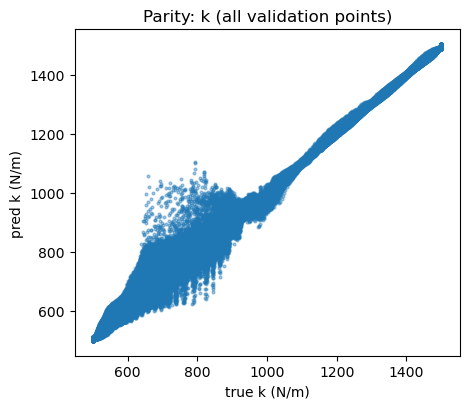

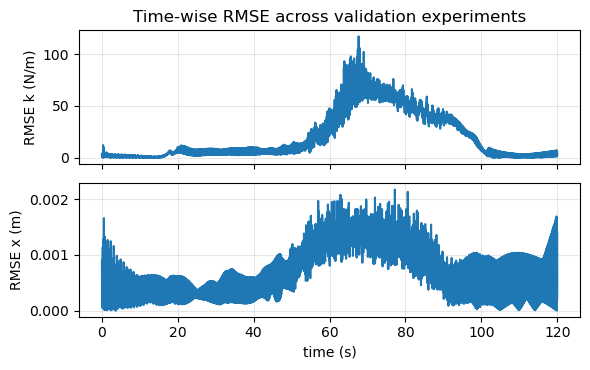

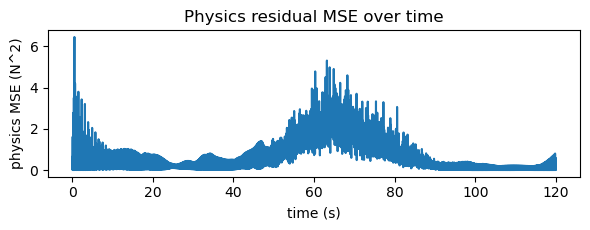

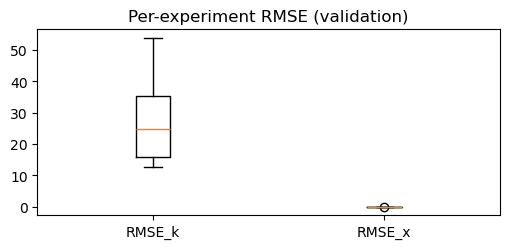

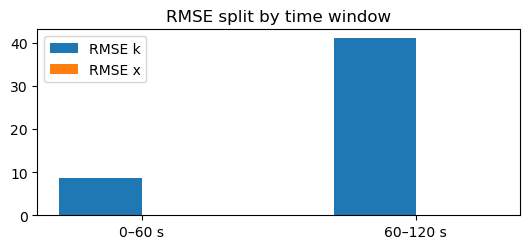

In [11]:
# === Section 7B: Metrics + richer plots for PINN soft-constraint ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

OUT_METRICS = REPO_ROOT / "PIML examples" / "metric_results" / "pinn_soft"
OUT_METRICS.mkdir(parents=True, exist_ok=True)

# Ground-truth aligned to predictions
k_true  = k[80:, :-1]      # (20, T-1)
x_true  = x[80:, 1:]       # (20, T-1)
v1_true = v[80:, 1:]       # (20, T-1)
a1_true = a[80:, 1:]       # (20, T-1)
F1_true = F[80:, 1:]       # (20, T-1)
t_al    = t[1:]            # (T-1,)

k_pred  = k0_pred          # (20, T-1)
x_pred  = x1_pred          # (20, T-1)

# ---------- metrics (mirrors metrics_v1.py) ----------
def rmse(sig, pred, squared=False):
    e = sig - pred
    val = np.mean(e**2)
    return val if squared else np.sqrt(val)

def mae(sig, pred):
    return np.mean(np.abs(sig - pred))

def rrse(sig, pred):
    e = sig - pred
    denom = np.sum((sig - sig.mean())**2) + 1e-12
    return np.sqrt(np.sum(e**2) / denom)

def nrmse(sig, pred):
    span = (sig.max() - sig.min()) + 1e-12
    return rmse(sig, pred) / span

def snr(sig, pred, dB=True):
    noise = sig - pred
    a_sig = np.sqrt(np.mean(sig**2)) + 1e-12
    a_noise = np.sqrt(np.mean(noise**2)) + 1e-12
    val = (a_sig / a_noise)**2
    return 10*np.log10(val) if dB else val

def trac(sig, pred):
    num = (np.sum(sig * pred))**2
    denom = (np.sum(sig * sig) * np.sum(pred * pred)) + 1e-12
    return num / denom

# per-experiment metrics (vectors of length 20)
rmse_k_per_exp = np.sqrt(np.mean((k_true - k_pred)**2, axis=1))
rmse_x_per_exp = np.sqrt(np.mean((x_true - x_pred)**2, axis=1))
mae_k_per_exp  = np.mean(np.abs(k_true - k_pred), axis=1)

# time-wise RMSE (collapse across experiments; shape (T-1,))
rmse_k_time = np.sqrt(np.mean((k_true - k_pred)**2, axis=0))
rmse_x_time = np.sqrt(np.mean((x_true - x_pred)**2, axis=0))

# physics residual at t+1 using *predicted* k_t and x_{t+1}, but measured v_{t+1}, a_{t+1}, F_{t+1}
residual = (1.0 * a1_true) + (0.2 * v1_true) + (k_pred * x_pred) - F1_true  # m=1, c=0.2
phys_mse_time = np.mean(residual**2, axis=0)
phys_mse_val  = float(np.mean(phys_mse_time))

# 0–60 vs 60–120 split
cut = 60.0
idx1 = t_al <  cut
idx2 = t_al >= cut

def rmse_split(sig, pred):
    return (rmse(sig[:, idx1], pred[:, idx1]), rmse(sig[:, idx2], pred[:, idx2]))

rmse_k_0_60,  rmse_k_60_120  = rmse_split(k_true, k_pred)
rmse_x_0_60,  rmse_x_60_120  = rmse_split(x_true, x_pred)
phys_0_60,    phys_60_120    = np.mean(residual[:, idx1]**2), np.mean(residual[:, idx2]**2)

# summary table (like metrics_v1 but scoped to PINN_soft)
summary = {
    "rmse_k":    rmse(k_true, k_pred),
    "mae_k":     mae(k_true, k_pred),
    "rrse_k":    rrse(k_true, k_pred),
    "nrmse_k":   nrmse(k_true, k_pred),
    "snr_k_dB":  snr(k_true, k_pred, dB=True),
    "trac_k":    trac(k_true, k_pred),
    "rmse_x":    rmse(x_true, x_pred),
    "phys_mse":  phys_mse_val,
    "rmse_k_0_60":   rmse_k_0_60,
    "rmse_k_60_120": rmse_k_60_120,
    "rmse_x_0_60":   rmse_x_0_60,
    "rmse_x_60_120": rmse_x_60_120,
    "phys_mse_0_60": float(phys_0_60),
    "phys_mse_60_120": float(phys_60_120),
}
summary_df = pd.DataFrame([summary])
summary_df.to_csv(OUT_METRICS / "summary.csv", index=False)

# save raw arrays for later comparisons
np.save(OUT_METRICS / "rmse_k_per_exp.npy", rmse_k_per_exp)
np.save(OUT_METRICS / "rmse_x_per_exp.npy", rmse_x_per_exp)
np.save(OUT_METRICS / "rmse_k_time.npy", rmse_k_time)
np.save(OUT_METRICS / "rmse_x_time.npy", rmse_x_time)
np.save(OUT_METRICS / "phys_mse_time.npy", phys_mse_time)

print("Summary metrics:\n", summary_df)

# ---------- richer plots ----------
# 1) Parity plot for k
plt.figure(figsize=(4.8,4.2))
plt.scatter(k_true.ravel(), k_pred.ravel(), s=4, alpha=0.4)
lims = [min(k_true.min(), k_pred.min()), max(k_true.max(), k_pred.max())]
plt.plot(lims, lims, linewidth=1)
plt.xlabel("true k (N/m)"); plt.ylabel("pred k (N/m)")
plt.title("Parity: k (all validation points)")
plt.tight_layout(); plt.savefig(OUT_PRED / "k_parity.png", dpi=300)

# 2) Time-wise error curves
fig, ax = plt.subplots(2,1, figsize=(6,3.8), sharex=True)
ax[0].plot(t_al, rmse_k_time); ax[0].set_ylabel("RMSE k (N/m)")
ax[1].plot(t_al, rmse_x_time); ax[1].set_ylabel("RMSE x (m)"); ax[1].set_xlabel("time (s)")
ax[0].set_title("Time-wise RMSE across validation experiments")
for a in ax: a.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(OUT_PRED / "rmse_time_curves.png", dpi=300)

# 3) Physics residual MSE vs time
plt.figure(figsize=(6,2.4))
plt.plot(t_al, phys_mse_time)
plt.xlabel("time (s)"); plt.ylabel("physics MSE (N^2)")
plt.title("Physics residual MSE over time")
plt.tight_layout(); plt.savefig(OUT_PRED / "physics_mse_time.png", dpi=300)

# 4) Boxplots per-experiment RMSE(k) and RMSE(x)
plt.figure(figsize=(5.2,2.6))
plt.boxplot([rmse_k_per_exp, rmse_x_per_exp], labels=["RMSE_k", "RMSE_x"])
plt.title("Per-experiment RMSE (validation)")
plt.tight_layout(); plt.savefig(OUT_PRED / "rmse_boxplots.png", dpi=300)

# 5) Split bars 0–60 vs 60–120
labels = ["0–60 s", "60–120 s"]
plt.figure(figsize=(5.4,2.6))
xpos = np.arange(2)
plt.bar(xpos-0.15, [rmse_k_0_60, rmse_k_60_120], width=0.3, label="RMSE k")
plt.bar(xpos+0.15, [rmse_x_0_60, rmse_x_60_120], width=0.3, label="RMSE x")
plt.xticks(xpos, labels); plt.legend()
plt.title("RMSE split by time window")
plt.tight_layout(); plt.savefig(OUT_PRED / "rmse_split_bars.png", dpi=300)

print("Saved plots to:", OUT_PRED)
print("Saved metrics to:", OUT_METRICS)
